# Here's a simple LightGBM starter - happy copying and editing!

**Version 7** comes with no feature engineering at all, so it’s great if you just want a clean, easy-to-follow reference. Public score: **0.97470**.

As of **Version 14**, the notebook achieved its highest public score of **0.97507**.

More new features or other improvements may be added in future versions.

In [1]:
# Print all file paths in the input directory
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


# Data Loading

In [2]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv")

In [3]:
# Check and print the count of missing values in each column of the dataframe

print(train_df.isnull().sum())
print(test_df.isnull().sum())

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


# Data Processing

In [4]:
# Add new features (More attempts can be made)
import numpy as np

def add_features(df):
    df = df.copy()
    
    def credit(x):
        credit_level = (x['default'] == 'no') + (x['housing'] == 'no') + (x['loan'] == 'no')
        return {3: 27, 2: 9, 1: 3}.get(credit_level, 0)
    df['credit'] = df.apply(lambda x: credit(x), axis=1)
    
    def risk(x):
        risk_level = (x['default'] == 'yes') + (x['housing'] == 'yes') + (x['loan'] == 'yes')
        return {3: 27, 2: 9, 1: 3}.get(risk_level, 0)
    df['risk'] = df.apply(lambda x: risk(x), axis=1)
    
    df['balance_log'] = df['balance'].where(df['balance'] > -1, 0).apply(np.log1p)
    df['duration_log'] = df['duration'].where(df['duration'] > -1, 0).apply(np.log1p)
    
    month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6, 'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    df['month'] = df['month'].map(month_map)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    df['age_bin'] = pd.cut(df['age'], bins=[0, 40, 70, 100], labels=[1, 2, 0], right=False)
    
    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

In [5]:
# Get all non-numeric columns from the training dataframe

cat_cols = train_df.select_dtypes(include="object").columns.tolist()
cat_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'poutcome']

In [6]:
# Iterate through each non-numeric column to compare unique values between train and test sets

for col in cat_cols:
    print(f"\"{col}\" colum:\n>>> {sorted(train_df[col].unique())}\n>>> {sorted(test_df[col].unique())}\n")

# This comparison helps verify:
# 1. If test set contains values not seen in training (out-of-domain categories)
# 2. If categorical encodings can be safely applied to both sets

"job" colum:
>>> ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
>>> ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

"marital" colum:
>>> ['divorced', 'married', 'single']
>>> ['divorced', 'married', 'single']

"education" colum:
>>> ['primary', 'secondary', 'tertiary', 'unknown']
>>> ['primary', 'secondary', 'tertiary', 'unknown']

"default" colum:
>>> ['no', 'yes']
>>> ['no', 'yes']

"housing" colum:
>>> ['no', 'yes']
>>> ['no', 'yes']

"loan" colum:
>>> ['no', 'yes']
>>> ['no', 'yes']

"contact" colum:
>>> ['cellular', 'telephone', 'unknown']
>>> ['cellular', 'telephone', 'unknown']

"poutcome" colum:
>>> ['failure', 'other', 'success', 'unknown']
>>> ['failure', 'other', 'success', 'unknown']



In [7]:
# from itertools import combinations

# for cols in combinations(cat_cols, 2):
#     col = "_".join(cols)
#     cat_cols.append(col)
#     train_df[col] = train_df[cols[0]].astype(str) + "_" + train_df[cols[1]].astype(str)
#     test_df[col] = test_df[cols[0]].astype(str) + "_" + test_df[cols[1]].astype(str)

In [8]:
# Add count encoding
from collections import Counter

for col in cat_cols:
    counts = train_df[col].value_counts()
    train_df[col + "_count"] = train_df[col].map(counts)
    test_df[col + "_count"] = test_df[col].map(counts).fillna(0)

In [9]:
# Prepare feature matrix (X) and target vector (y) for training, and feature matrix (X_test) for testing

X = train_df.drop(["y", "id"], axis=1)
y = train_df["y"]
X_test = test_df.drop(["id"], axis=1)

In [10]:
# Map non-numeric columns to numeric values using LabelEncoder for both training and test sets
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    X_test[col] = le.transform(X_test[col])

# Model Training

In [11]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Use 5-fold stratified cross-validation
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
y_probs = np.zeros(len(X_test))
models = []
val_aucs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Training fold {fold + 1}/{n_splits} >>>")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        objective="binary",
        metric="auc",
        n_estimators=20000,
        learning_rate=0.04770062672645345,
        num_leaves=110,
        max_depth=15,
        min_child_samples=7,
        subsample=0.7535901856612678,
        colsample_bytree=0.3086234831127026,
        reg_alpha=1.493378518925405,
        reg_lambda=1.8558078940110203,
        max_bin=5927,
        random_state=42,
        verbosity=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(500),
            lgb.log_evaluation(period=500)
        ]
    )
    
    models.append(model)
    
    # Average predictions across all folds
    y_probs += model.predict_proba(X_test)[:, 1] / n_splits
    
    # Val AUC
    val_pred = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred)
    val_aucs.append(val_auc)

print(f"Mean AUC: {np.mean(val_aucs):.6f}")

Training fold 1/5 >>>
Training until validation scores don't improve for 500 rounds
[500]	valid_0's auc: 0.972868
[1000]	valid_0's auc: 0.974055
[1500]	valid_0's auc: 0.974474
[2000]	valid_0's auc: 0.97464
[2500]	valid_0's auc: 0.974714
[3000]	valid_0's auc: 0.97473
[3500]	valid_0's auc: 0.974691
Early stopping, best iteration is:
[3044]	valid_0's auc: 0.974746
Training fold 2/5 >>>
Training until validation scores don't improve for 500 rounds
[500]	valid_0's auc: 0.971745
[1000]	valid_0's auc: 0.972959
[1500]	valid_0's auc: 0.973457
[2000]	valid_0's auc: 0.97366
[2500]	valid_0's auc: 0.973671
[3000]	valid_0's auc: 0.973645
Early stopping, best iteration is:
[2553]	valid_0's auc: 0.973677
Training fold 3/5 >>>
Training until validation scores don't improve for 500 rounds
[500]	valid_0's auc: 0.971657
[1000]	valid_0's auc: 0.973041
[1500]	valid_0's auc: 0.973437
[2000]	valid_0's auc: 0.973596
[2500]	valid_0's auc: 0.973639
[3000]	valid_0's auc: 0.973619
Early stopping, best iteration is

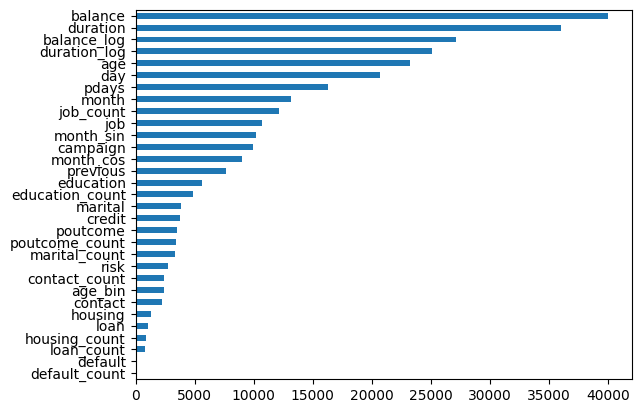

In [12]:
# Plot horizontal bar chart of feature importances if model supports it
# This helps us add new features or remove useless ones

all_importances = []

for model in models:
    if hasattr(model, "feature_importances_"):
        all_importances.append(model.feature_importances_)

if all_importances:
    avg_importances = pd.Series(np.mean(all_importances, axis=0), index=X.columns)
    avg_importances.sort_values().plot(kind='barh')

# Results Submission

In [13]:
submission = pd.DataFrame({"id": test_df["id"], "y": y_probs})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,y
0,750000,0.004556
1,750001,0.129780
2,750002,0.000148
3,750003,0.000029
4,750004,0.008448
